In [42]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
import torch
import model.transformer
import model.data as data
import model.constants as constants
import time
import matplotlib.pyplot as plt
from IPython.display import display
print("START: ", time.perf_counter())
if constants.DEBUG: print("Start of file", time.perf_counter())
transformer = model.transformer.Transformer()
if constants.DEBUG: print("Transform made", time.perf_counter())
dev_cutoff = int(0.9 * len(data.full_text)) # TODO add test split
train_data = data.full_text[:dev_cutoff]
dev_data = data.full_text[dev_cutoff:]
X_batch, Y_batch = data.GetRandomBatch(train_data)

START:  66176.640916625


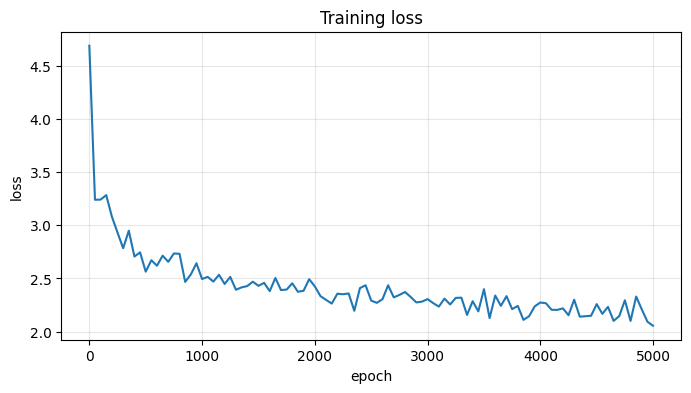

loss: 4.687386989593506
loss: 3.2396063804626465
loss: 3.2408885955810547
loss: 3.2832393646240234
loss: 3.0807018280029297
loss: 2.9306206703186035
loss: 2.7836480140686035
loss: 2.9482975006103516
loss: 2.705538749694824
loss: 2.7447710037231445
loss: 2.5635251998901367
loss: 2.6705427169799805
loss: 2.619365692138672
loss: 2.7135043144226074
loss: 2.6560707092285156
loss: 2.734316349029541
loss: 2.7315409183502197
loss: 2.4671273231506348
loss: 2.5368614196777344
loss: 2.642547130584717
loss: 2.4940648078918457
loss: 2.5144410133361816
loss: 2.4696521759033203
loss: 2.534010410308838
loss: 2.447892665863037
loss: 2.514110565185547
loss: 2.393409013748169
loss: 2.415597915649414
loss: 2.4275946617126465
loss: 2.4690651893615723
loss: 2.4301581382751465
loss: 2.4581284523010254
loss: 2.3804352283477783
loss: 2.5038087368011475
loss: 2.390458106994629
loss: 2.3951447010040283
loss: 2.4539737701416016
loss: 2.3743972778320312
loss: 2.3841171264648438
loss: 2.492657423019409
loss: 2.4249

In [44]:

loss_steps = []
loss_history = []
plot_every = max(1, constants.EPOCHS // 100)

fig, ax = plt.subplots(figsize=(8, 4))
(loss_line,) = ax.plot([], [])
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Training loss")
ax.grid(True, alpha=0.3)
plot_handle = display(fig, display_id=True)

for i in range(constants.EPOCHS):
    if constants.DEBUG: print("Start", time.perf_counter())
    X_batch, Y_batch = data.GetRandomBatch(train_data);
    if constants.DEBUG: print("Got batches", time.perf_counter())
    out = transformer.forward(X_batch)
    if constants.DEBUG: print("Forwad complete", time.perf_counter())
    B, T, C = out.shape
    loss = transformer.backward(out.view(B*T, C), Y_batch.view(B*T))
    if constants.DEBUG: print("Backward complete", time.perf_counter())
    if (i % plot_every == 0) or (i == constants.EPOCHS - 1):
        print(f"loss: {loss}")
        loss_steps.append(i)
        loss_history.append(loss)
        loss_line.set_data(loss_steps, loss_history)
        ax.relim()
        ax.autoscale_view()
        if plot_handle is not None:
            plot_handle.update(fig)
        else:
            fig.canvas.draw_idle()
            plt.pause(0.001)

plt.close(fig)

In [45]:
def DecodeTokenList(token_list):
    return data.decode(token_list)


def TestModel(transformer, data_source, n_tokens=10):
    X_test, _ = data.GetRandomBatch(data_source)
    # X_test = X_batch
    context = X_test[0].clone()
    start_context = context.clone()

    print("START:")
    print(DecodeTokenList(context))

    generated_tokens = []

    for i in range(n_tokens):
        # Add fake batch dimension: [T] -> [1, T]
        context_batch = context.view(1, constants.CONTEXT_WINDOW_SIZE)

        # Your transformer currently expects N_BATCHES exactly,
        # so repeat the same context N_BATCHES times.
        context_batch = context_batch.repeat(constants.N_BATCHES, 1)

        # Predict next token from the final position in the first batch row
        with torch.no_grad():
            logits = transformer.forward(context_batch)
        pred = logits[0, -1].argmax(dim=-1)

        generated_tokens.append(pred)

        # Slide context window left and append prediction
        context = torch.cat([context[1:], pred.view(1)], dim=0)

        print(f"PRED {i + 1}: {data.untokenizer_map[int(pred)]!r}")

    print("\nGENERATED:")
    print(DecodeTokenList(generated_tokens))

    print("\nFULL:")
    print(DecodeTokenList(start_context) + DecodeTokenList(generated_tokens))

TestModel(transformer, train_data, n_tokens=100)

START:
wel in a ten-times-barr'd-up che
PRED 1: ' '
PRED 2: 't'
PRED 3: 'h'
PRED 4: 'e'
PRED 5: ' '
PRED 6: 't'
PRED 7: 'h'
PRED 8: 'e'
PRED 9: ' '
PRED 10: 't'
PRED 11: 'h'
PRED 12: 'e'
PRED 13: ' '
PRED 14: 't'
PRED 15: 'h'
PRED 16: 'e'
PRED 17: ' '
PRED 18: 't'
PRED 19: 'h'
PRED 20: 'e'
PRED 21: ' '
PRED 22: 't'
PRED 23: 'h'
PRED 24: 'e'
PRED 25: ' '
PRED 26: 't'
PRED 27: 'h'
PRED 28: 'e'
PRED 29: ' '
PRED 30: 't'
PRED 31: 'h'
PRED 32: 'e'
PRED 33: ' '
PRED 34: 't'
PRED 35: 'h'
PRED 36: 'e'
PRED 37: ' '
PRED 38: 't'
PRED 39: 'h'
PRED 40: 'e'
PRED 41: ' '
PRED 42: 't'
PRED 43: 'h'
PRED 44: 'e'
PRED 45: ' '
PRED 46: 't'
PRED 47: 'h'
PRED 48: 'e'
PRED 49: ' '
PRED 50: 't'
PRED 51: 'h'
PRED 52: 'e'
PRED 53: ' '
PRED 54: 't'
PRED 55: 'h'
PRED 56: 'e'
PRED 57: ' '
PRED 58: 't'
PRED 59: 'h'
PRED 60: 'e'
PRED 61: ' '
PRED 62: 't'
PRED 63: 'h'
PRED 64: 'e'
PRED 65: ' '
PRED 66: 't'
PRED 67: 'h'
PRED 68: 'e'
PRED 69: ' '
PRED 70: 't'
PRED 71: 'h'
PRED 72: 'e'
PRED 73: ' '
PRED 74: 't'
PRED 75

In [46]:
import model.shared

@torch.no_grad()
def CompareContexts(model, ctx1, ctx2):
    logits1 = model.forward(ctx1.unsqueeze(0))[:, -1, :]
    logits2 = model.forward(ctx2.unsqueeze(0))[:, -1, :]

    probs1 = torch.softmax(logits1, dim=-1)
    probs2 = torch.softmax(logits2, dim=-1)

    print("max abs logit diff:", (logits1 - logits2).abs().max().item())
    print("max abs prob diff:", (probs1 - probs2).abs().max().item())
    print("top ctx1:", probs1[0].topk(10))
    print("top ctx2:", probs2[0].topk(10))

ctx1 = torch.tensor(data.encode("To be, or not to be, that is"), device=model.shared.device)[-constants.CONTEXT_WINDOW_SIZE:]
ctx2 = torch.tensor(data.encode("zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz"), device=model.shared.device)[-constants.CONTEXT_WINDOW_SIZE:]

CompareContexts(transformer, ctx1, ctx2)

RuntimeError: The size of tensor a (28) must match the size of tensor b (32) at non-singleton dimension 1